In [ ]:
%matplotlib inline

ndevices = 30
import os
os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={ndevices}"
os.environ["OMP_NUM_THREADS"] = f"{ndevices}"
os.environ["MKL_NUM_THREADS"] = f"{ndevices}"
os.environ["NUMEXPR_NUM_THREADS"] = f"{ndevices}"
os.environ["OPENBLAS_NUM_THREADS"] = f"{ndevices}"
os.environ["VECLIB_MAXIMUM_THREADS"] = f"{ndevices}"
os.environ["NUMBA_NUM_THREADS"] = f"{ndevices}"
os.environ["JAX_TRACEBACK_FILTERING"] = "off"

import multiprocessing
import pandas as pd
import sys
import glob
from functools import partial
from astropy.io import fits, ascii
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table
from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value, wCDM, LambdaCDM
import scipy.stats as st
from scipy.optimize import minimize
from scipy.signal import fftconvolve
import warnings
import h5py
import emcee
import corner
from scipy import stats
import time
plt.style.use('style.mplstyle')

### Read the light curve fitting and quasar parameters

In [14]:
bands = ['u', 'g', 'r', 'i', 'z']#, 'y']
bands_idx = {b: i for i, b in enumerate(bands)}

def read_quasars_from_hdf5(file_path):
    quasar_list = []
    with h5py.File(file_path, "r") as hdf:
        for group_name in hdf.keys():
            group = hdf[group_name]
            quasar = {"object_id": group_name}
            for key, value in group.attrs.items():
                quasar[key] = value
            for sub_group_name in group.keys():
                sub_group = group[sub_group_name]
                quasar[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
            quasar_list.append(quasar)
    return quasar_list

hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    

def populate_sdss_fields(d):
    i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
    if len(i) == 0:
        print(f"Warning: {d['sdss_name']} not found in SDSS data")
        return d
    i = i[0]
    if np.any(fits_data_2['PSFFLUX'][i,:] <= 0):
        return d
    d['log_mbh'] = fits_data['LOGMBH'][i]
    d['log_mbh_err'] = fits_data['LOGMBH_ERR'][i]
    d['log_ledd_ratio'] = fits_data['LOGLEDD_RATIO'][i]
    d['log_ledd_ratio_err'] = fits_data['LOGLEDD_RATIO_ERR'][i]
    d['ebv'] = fits_data['EBV'][i]
    d['M_i'] = fits_data_2['M_I'][i]
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        d['apparent_mag_z'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,4]) + 22.5
        d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 22.5
        d['apparent_mag_r'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,2]) + 22.5
        d['apparent_mag_g'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,1]) + 22.5
        d['apparent_mag_u'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,0]) + 22.5
        d['apparent_mag_z_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,4])/fits_data_2['PSFFLUX'][i,4]
        d['apparent_mag_i_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,3])/fits_data_2['PSFFLUX'][i,3]
        d['apparent_mag_r_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,2])/fits_data_2['PSFFLUX'][i,2]
        d['apparent_mag_g_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,1])/fits_data_2['PSFFLUX'][i,1]
        d['apparent_mag_u_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,0])/fits_data_2['PSFFLUX'][i,0]
        d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
    if any(issubclass(warning.category, RuntimeWarning) for warning in w):
        print(f"RuntimeWarning occurred for {d['sdss_name']}")
        print(fits_data_2['PSFFLUX'][i,:])
        print(w)
    return d

quasar_list = read_quasars_from_hdf5("data/may12_objs_tauwavelength_taublr_redbands_ds4_merged.h5")
#quasar_list = read_quasars_from_hdf5("data/may13_objs_tauwavelength_taublr_freebreak_merged.h5")

print("Number of quasars loaded:", len(quasar_list))

filtered_quasar_list = []
for q in quasar_list:
    accept = True    
    for i, b in enumerate(q['clean_bands']):
        if len(q['magerrs'][b]) == 0:
            continue
        if not ((10**q[f'log_sigma_band'][bands_idx[b]])**2 > 1*(np.nanmean(q['magerrs'][b])**2 + (10**q[f'log_jitter'][i])**2)):
            accept = False

    populate_sdss_fields(q)
    #calc_lam_RF(q)
    #q['delta_time'] = q['times']['r'].max() - q['times']['r'].min()
    if True:
        filtered_quasar_list.append(q)


df = pd.DataFrame(filtered_quasar_list)
#df = df.set_index('object_id')
#df = df.drop(columns=['log_jitter', 'magerrs_mean', 'log_sigma_band', 'log_sigma_band_err', 'clean_bands'])
df = df.drop(columns=['mags', 'times', 'magerrs'])

df_all = df.copy()

# Remove infinite values from numeric columns
columns_with_nans = df.columns[df.isna().any()].tolist()
print("Columns with NaNs:", columns_with_nans)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].where(~np.isinf(df[numeric_cols]), np.nan)
df = df.dropna()

# data cuts
# df = df[df['log_sigma_UV'] < 0]
# df = df[df['log_tau_UV_RF'] > 1]
# df = df[df['log_lbol'] > 44]
# df = df[df['log_mbh'] > 1]
# df = df[df['apparent_mag_i'] < 30]
# #df = df[df['M_i'] > -27]
#df = df[df['ebv'] < 0.05]

num_quasars_z_0_1 = len(df[(df['z'] > 0) & (df['z'] <= 1)])
num_quasars_z_gt_3 = len(df[df['z'] > 3])

print("Number of quasars with 0 < z <= 1:", num_quasars_z_0_1)
print("Number of quasars with z > 3:", num_quasars_z_gt_3)
print("Final number of quasars:", len(df))
df.head()

Number of quasars loaded: 1479
Columns with NaNs: []
Number of quasars with 0 < z <= 1: 350
Number of quasars with z > 3: 81
Final number of quasars: 1479


,object_id,clean_bands,dec,eta_A1,eta_A1_err,eta_A2,eta_A2_err,eta_tau1,eta_tau1_err,eta_tau2,...,apparent_mag_i,apparent_mag_r,apparent_mag_g,apparent_mag_u,apparent_mag_z_err,apparent_mag_i_err,apparent_mag_r_err,apparent_mag_g_err,apparent_mag_u_err,color
0,1385049,"[u, g, r, i, z]",-0.708190,0.829436,0.058761,0.801089,0.111452,0.022554,0.094835,-0.436581,...,19.350080,19.411097,19.665806,19.744036,0.056119,0.024710,0.017769,0.030145,0.034751,0.393955
1,1387470,"[u, g, r, i, z]",-0.175792,0.964604,0.077742,1.042578,0.088084,0.154766,0.074410,-0.362260,...,19.685448,19.604025,19.834627,19.929401,0.075555,0.040357,0.029988,0.023662,0.034297,0.243955
2,1387735,"[u, g, r, i, z]",-0.676568,0.747824,0.075055,0.751545,0.100375,-0.017953,0.041485,-0.516309,...,19.645576,19.643301,19.714458,19.952137,0.055411,0.024917,0.018819,0.035953,0.034929,0.306561
3,1387875,"[u, g, r, i, z]",-0.851407,0.838809,0.071501,0.939608,0.128011,-0.017657,0.098766,-0.423335,...,20.027744,20.017122,20.507414,20.407162,0.093236,0.028000,0.024979,0.038794,0.052243,0.379419
4,1388307,"[u, g, r, i, z]",0.812130,1.022318,0.081596,1.254194,0.106482,0.013433,0.078658,-0.319234,...,21.218897,21.989798,22.286879,22.765182,0.221938,0.060202,0.079553,0.087107,0.284784,1.546286


In [154]:
def drop_faintest_bin(df, z_col='z', mag_col='apparent_mag_i', z_bins_width=0.1, mag_margin=0.5):
    """
    Drop quasars within mag_margin magnitude of the faintest quasar in each redshift bin.

    Parameters:
        df (pd.DataFrame): Input dataframe containing redshifts and apparent magnitudes.
        z_col (str): Column name for redshift.
        mag_col (str): Column name for apparent magnitude.
        z_bins_width (float): Width of each redshift bin.
        mag_margin (float): Magnitude range to drop above the faintest object.

    Returns:
        pd.DataFrame: Filtered dataframe.
    """
    df = df.copy().reset_index(drop=True)

    # Create redshift bins
    z_min, z_max = df[z_col].min(), df[z_col].max()
    z_bins = np.arange(z_min, z_max + z_bins_width, z_bins_width)

    # Assign bin labels
    df['z_bin'] = pd.cut(df[z_col], bins=z_bins, include_lowest=True)

    # Container for indices to drop
    indices_to_drop = []

    # Iterate over each redshift bin
    for bin_interval, group in df.groupby('z_bin'):
        if len(group) == 0:
            continue
        faintest_mag = group[mag_col].max()  # Faintest magnitude (largest value)
        
        # Identify objects within mag_margin from the faintest magnitude
        drop_condition = group[mag_col] >= (faintest_mag - mag_margin)
        indices_to_drop.extend(group[drop_condition].index.tolist())

    # Drop identified indices
    filtered_df = df.drop(indices_to_drop).reset_index(drop=True)

    # Drop auxiliary bin column
    filtered_df = filtered_df.drop(columns='z_bin')

    return filtered_df

df = drop_faintest_bin(df, z_col='z', mag_col='apparent_mag_i', z_bins_width=0.1, mag_margin=1)

/tmp/ipykernel_303888/4201149098.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_interval, group in df.groupby('z_bin'):


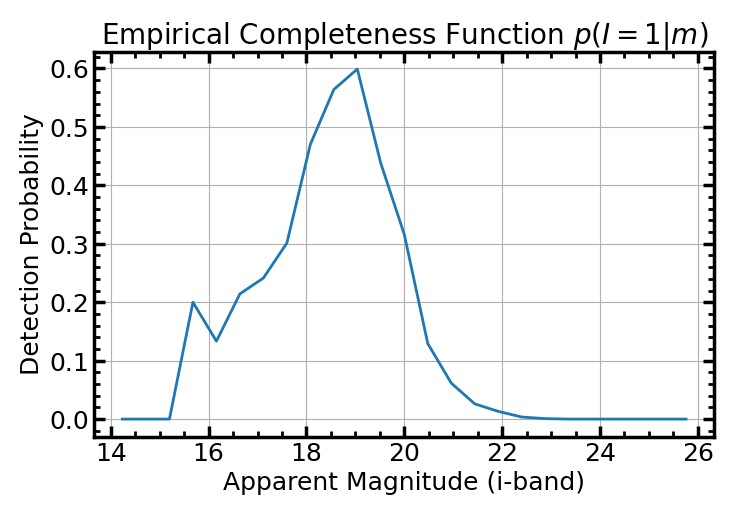


\caption{
Empirical completeness function $p(I=1|m)$ as a function of apparent magnitude in the $i$-band. 
The completeness ratio is derived by comparing the observed apparent magnitude distribution to the true distribution. 
This function is used to account for selection effects in the analysis.
}



In [15]:


import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

n_bins_completeness = 26

# Load the magnitude true dist data
file_path = "stacked_sampled_apparent_magnitudes.h5"

with h5py.File(file_path, "r") as f:
    mags_true = f["stacked_apparent_magnitudes"][:]

mags_obs = df['apparent_mag_i'].values

# Clean both datasets
mags_true = mags_true[np.isfinite(mags_true)]
mags_obs = mags_obs[np.isfinite(mags_obs)]

# Histogram bins
bin_edges = np.linspace(14, 26, n_bins_completeness)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
dm = np.diff(bin_edges)[0]

# Histogram both samples
hist_true, _ = np.histogram(mags_true, bins=bin_edges)
hist_obs, _ = np.histogram(mags_obs, bins=bin_edges)

# Avoid division by zero
mask = hist_true > 0
completeness_ratio = np.zeros_like(hist_true, dtype=float)
completeness_ratio[mask] = hist_obs[mask] / hist_true[mask]

# Smooth or regularize if needed
# Apply Gaussian smoothing to the completeness ratio
#completeness_ratio = gaussian_filter1d(completeness_ratio, sigma=0.5)
completeness_ratio = np.clip(completeness_ratio, 0, 1)

# Interpolation
p_detect_interp = interp1d(
    bin_centers,
    completeness_ratio,
    kind='quadratic',
    bounds_error=False,
    fill_value=(1.0, 0.0)
)

# Plot for inspection
plt.figure(figsize=(8, 5))
plt.plot(bin_centers, completeness_ratio, label="Empirical Completeness $p(I=1|m)$", lw=2)
plt.xlabel("Apparent Magnitude (i-band)")
plt.ylabel("Detection Probability")
plt.title("Empirical Completeness Function $p(I=1|m)$")
plt.grid(True)
plt.savefig("plots/completeness_function.pdf", dpi=300, bbox_inches="tight")
#plt.legend(fontsize=10)
plt.show()

# LaTeX caption for the figure
latex_caption = r"""
\caption{
Empirical completeness function $p(I=1|m)$ as a function of apparent magnitude in the $i$-band. 
The completeness ratio is derived by comparing the observed apparent magnitude distribution to the true distribution. 
This function is used to account for selection effects in the analysis.
}
"""
print(latex_caption)

### Load the SNIa data

In [4]:
url = 'https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true'
df_pantheon = pd.read_csv(url, delim_whitespace=True)
df_pantheon.keys()

/tmp/ipykernel_1836710/2347323853.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_pantheon = pd.read_csv(url, delim_whitespace=True)


Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='object')

In [34]:
lambda_pivot = {
    'u': 3543,  # SDSS u-band
    'g': 4770,  # SDSS g-band
    'r': 6231,  # SDSS r-band
    'i': 7625,  # SDSS i-band
    'z': 9134,  # SDSS z-band
    'y': 9633,  # PS1 y-band
}

def log_broken_pl(lam, lam_s, d1, d2, ds=2.0):
    x = lam / lam_s
    log_f = -np.log10(
        np.power(x, d1) * np.power(1.0 + np.power(x, ds), (d2 - d1) / ds)
    )
    return log_f

lambda_ref = 2500 # Any reference wavelength
lambda_s_RF = df["lam_s"]
#lambda_s_RF = 2600

eta_tau1 = df['eta_tau1']
eta_tau2 = df['eta_tau2']
df['log_tau_UV_RF'] = df['log_tau'] - np.log10(1 + df['z']) + log_broken_pl(lambda_ref, lambda_s_RF, eta_tau1, eta_tau2, ds=4.0)

eta_A1 = df['eta_A1']
eta_A2 = df['eta_A2']
df['log_sigma_UV'] = df['log_sigma'] - np.log10(1 + df['z']) + log_broken_pl(lambda_ref, lambda_s_RF, eta_A1, eta_A2, ds=4.0)

100%|██████████| 500/500 [00:40<00:00, 12.48it/s]


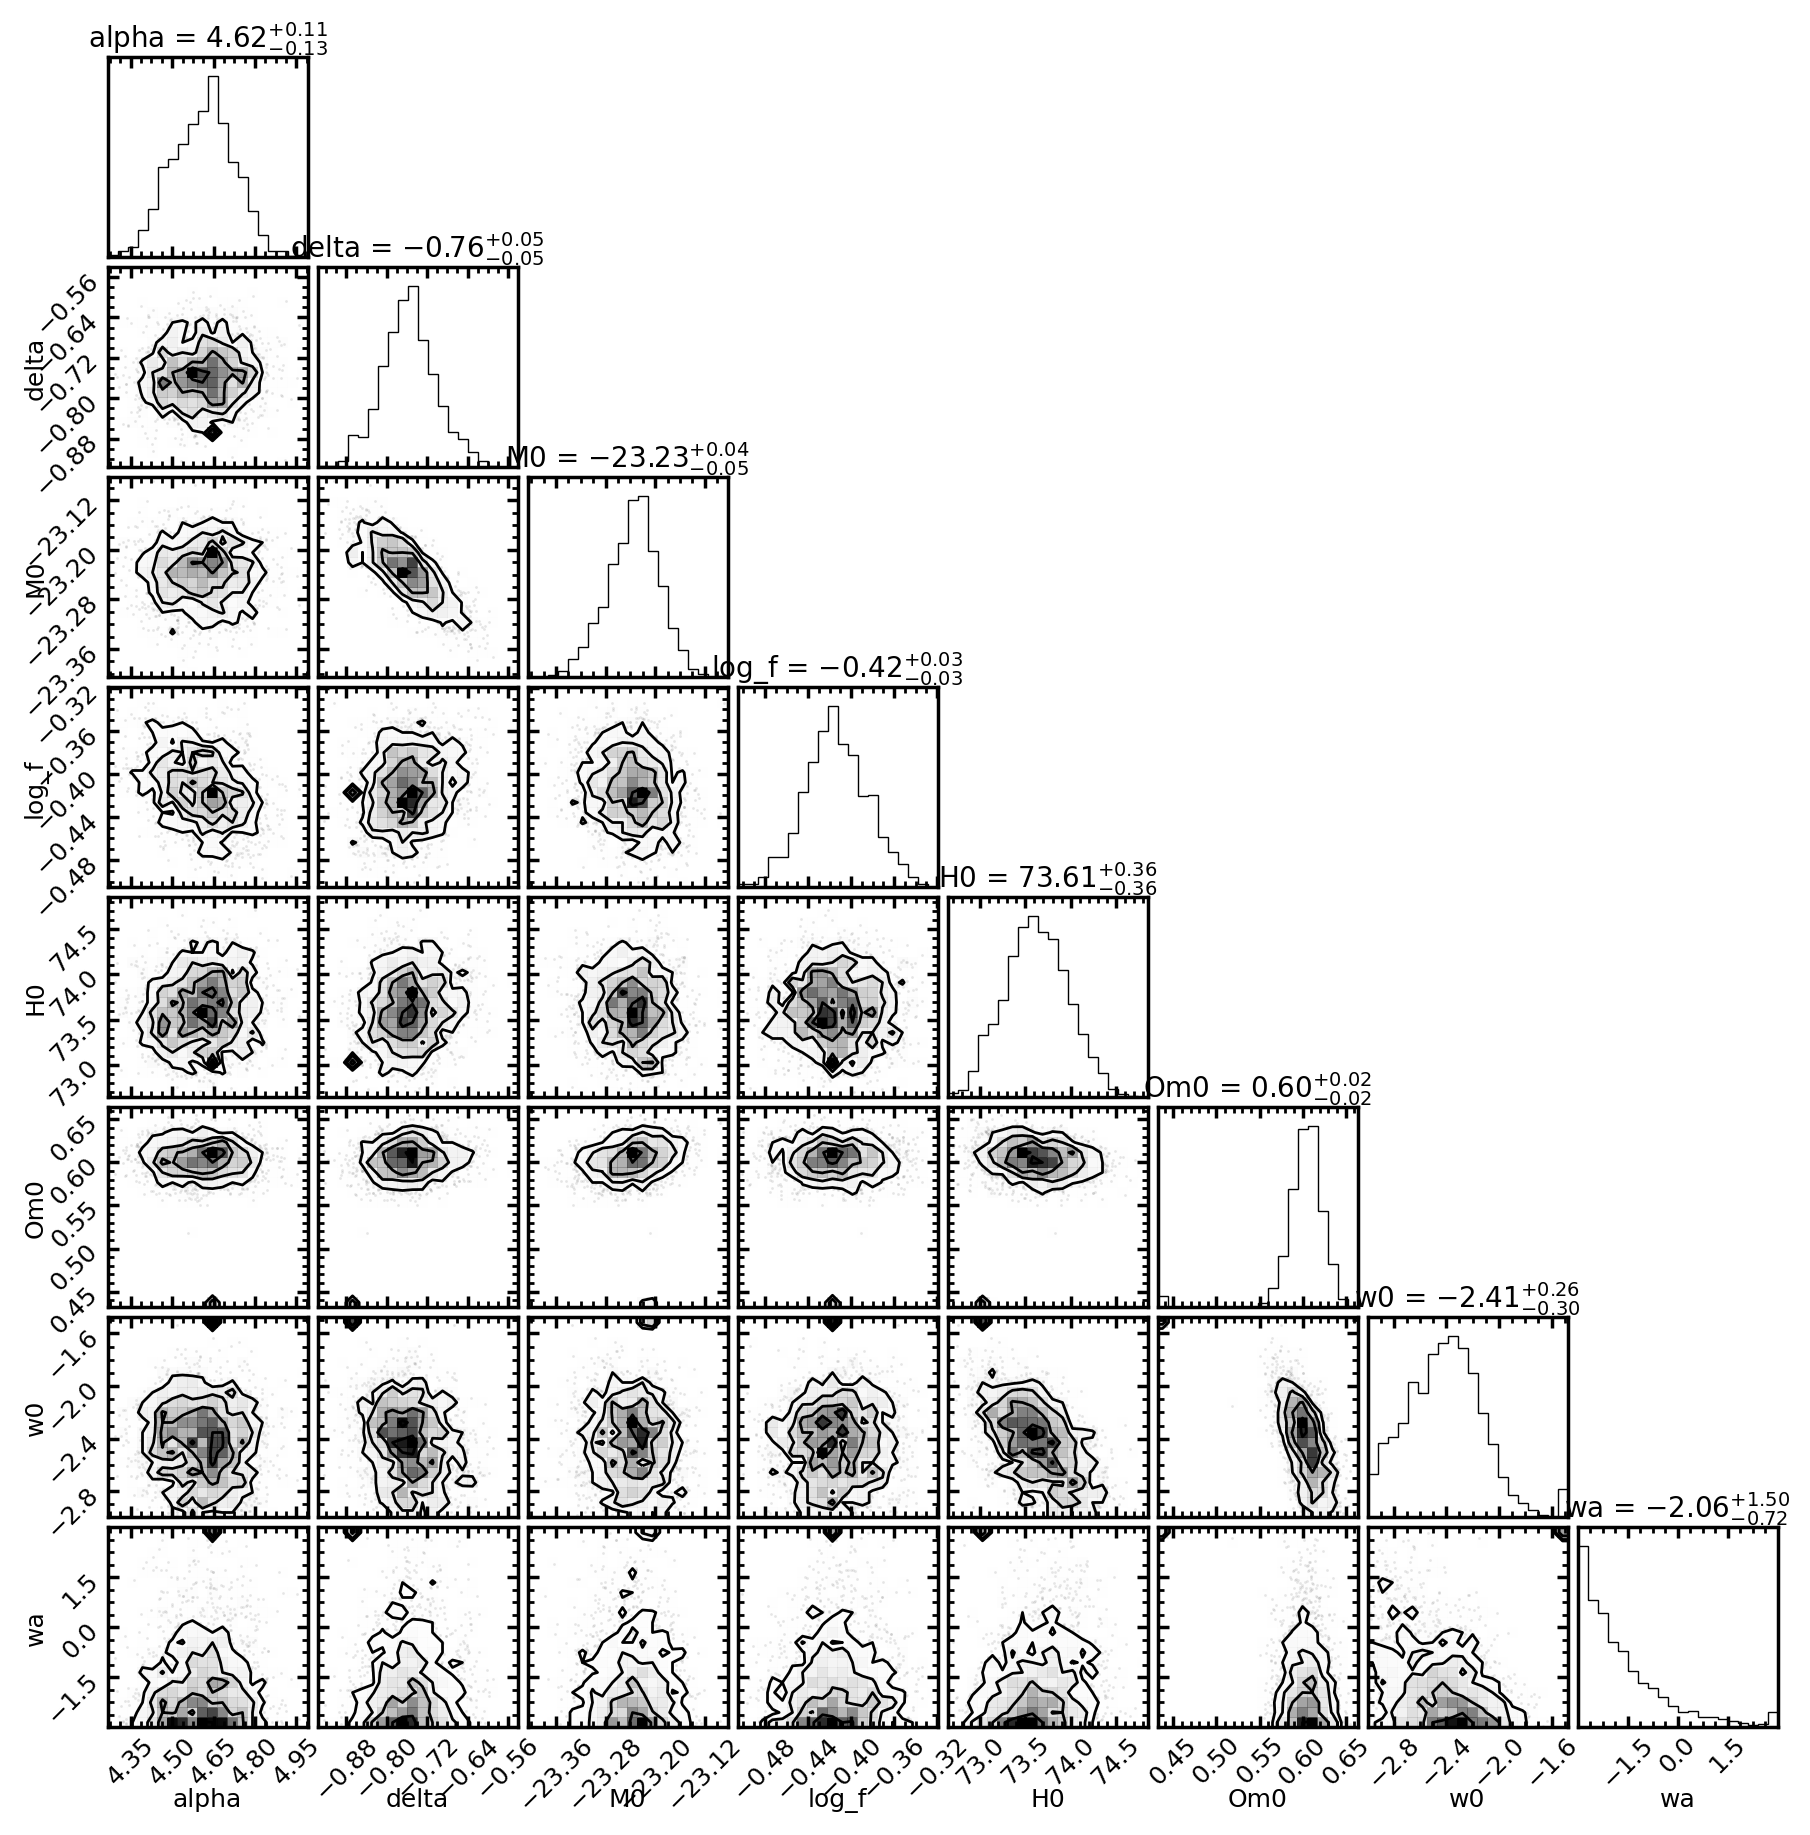


Parameter Estimates:
alpha: 4.616 +0.107/-0.127
delta: -0.758 +0.054/-0.050
M0: -23.233 +0.037/-0.047
log_f: -0.415 +0.031/-0.027
H0: 73.614 +0.355/-0.355
Om0: 0.604 +0.016/-0.019
w0: -2.412 +0.263/-0.304
wa: -2.056 +1.499/-0.719


In [26]:
# --- Constants ---
lambda_pivot = {
    'u': 3543,  # SDSS u-band
    'g': 4770,  # SDSS g-band
    'r': 6231,  # SDSS r-band
    'i': 7625,  # SDSS i-band
    'z': 9134,  # SDSS z-band
    'y': 9633,  # PS1 y-band
}
z_pivot = df['z'].median()
sigma_pivot = -0.8
tau_pivot = 2.0

# --- Model Functions ---

def M_model_single(M0, alpha, delta, log_sigma_UV, log_tau_UV_RF):
    """Variability-luminosity relation for one AGN."""
    return M0 + alpha * (log_sigma_UV - sigma_pivot) + delta * (log_tau_UV_RF - tau_pivot)

def K_corr(z, alpha_nu=-0.5):
    """Simple K-correction."""
    return -2.5 * (1 + alpha_nu) * np.log10(1 + z)

# --- Build Empirical Completeness Function ---
mag_eval = np.linspace(14, 28, 500)
dm = mag_eval[1] - mag_eval[0]
p_detect = p_detect_interp(mag_eval)

# --- Priors ---
priors = {
    "alpha": (0, 10),
    "delta": (-5, 5),
    "M0": (-30, -10),
    "log_f": (-3, 1),
    "H0": (60, 80),
    "Om0": (0.2, 0.7),
    "w0": (-3, 0),
    "wa": (-3, 3),
}
labels = list(priors.keys())

# --- Log-likelihood ---
def log_likelihood(theta):
    alpha, delta, M0, log_f, H0, Om0, w0, wa = theta

    # Prior bounds check
    for i, (key, val) in enumerate(priors.items()):
        if not (val[0] < theta[i] < val[1]):
            return -np.inf

    # Cosmology model
    #cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    cosmo = Flatw0waCDM(H0=H0, Om0=Om0, w0=w0, wa=wa)

    # AGN data vectors
    z = df['z'].values
    m_obs = df['apparent_mag_i'].values
    m_err = df['apparent_mag_i_err'].values
    log_sigma = df['log_sigma_UV'].values
    log_tau = df['log_tau_UV_RF'].values
    log_sigma_err = df['log_sigma_UV_err'].values
    log_tau_err = df['log_tau_UV_RF_err'].values

    # Cosmology predictions
    mu_cosmo = cosmo.distmod(z).value
    Kcorr = K_corr(z) + K_corr(2)
    M_pred = M_model_single(M0, alpha, delta, log_sigma, log_tau) 
    mu_pred = m_obs - M_pred - Kcorr

    # AGN uncertainty
    mu_err = np.sqrt(
        m_err**2 +
        (alpha * log_sigma_err)**2 +
        (delta * log_tau_err)**2 +
        (K_corr(z) * 0.05)**2 +
        #(2.5 * 0.3 * np.log10(1 + z))**2 +
        (0.055 * z)**2 +
        np.exp(2 * log_f)
    )

    # Residuals
    dmu = mu_pred - mu_cosmo
    ll_agn = np.sum(stats.norm.logpdf(dmu, scale=mu_err))

    # --- Selection Correction ---
    m_model = M_pred + mu_cosmo
    integrals = np.zeros(len(df))
    unique_errors = np.round(mu_err, 4)
    unique_vals = np.unique(unique_errors)

    for sigma in unique_vals:
        mask = (np.abs(mu_err - sigma) < 1e-6)
        if np.sum(mask) == 0:
            continue

        kernel = stats.norm.pdf(mag_eval, loc=0.0, scale=sigma)
        conv = fftconvolve(p_detect, kernel, mode="same") * dm
        integrals[mask] = np.interp(m_model[mask], mag_eval, conv)

    norm_correction = np.sum(np.log(integrals + 1e-20))  # avoid log(0)

    # --- SNIa likelihood ---
    mu_snia = cosmo.distmod(df_pantheon['zHD']).value
    dmu_snia = df_pantheon['MU_SH0ES'] - mu_snia
    ll_snia = np.sum(stats.norm.logpdf(dmu_snia, scale=df_pantheon['MU_SH0ES_ERR_DIAG']))
    #ll_snia = -0.5 * np.dot(dmu_snia, np.linalg.solve(covariance_matrix, dmu_snia)) + np.log(1/(2*np.pi * np.sqrt(np.linalg.det(covariance_matrix)))) # Slow

    # Total
    return ll_snia + ll_agn - norm_correction


# --- Full MCMC Pipeline ---
def run_mcmc_pipeline():
    ndim = len(priors)
    nwalkers = 30*2
    nsteps_burnin = 1000
    nsteps_production = 500

    initial_pos = np.array([
        np.random.uniform(low, high, nwalkers) for low, high in priors.values()
    ]).T

    ncpus = multiprocessing.cpu_count()  # or set manually
    pool = multiprocessing.Pool(processes=ncpus)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, pool=pool)

    state = sampler.run_mcmc(initial_pos, nsteps_burnin, progress=True)

    sampler.reset()
    sampler.run_mcmc(state, nsteps_production, progress=True)

    flat_samples = sampler.get_chain(discard=0, thin=15, flat=True)

    fig = corner.corner(flat_samples, labels=labels, truths=None, show_titles=True, title_fmt=".2f")
    plt.savefig("plots/corner_plot.png", dpi=200)
    plt.show()
    plt.close()

    return flat_samples, sampler

flat_samples, sampler_agn = run_mcmc_pipeline()
print("\nParameter Estimates:")
for i, label in enumerate(labels):
    median = np.percentile(flat_samples[:, i], 50)
    low = np.percentile(flat_samples[:, i], 16)
    high = np.percentile(flat_samples[:, i], 84)
    err_low = median - low
    err_high = high - median
    print(f"{label}: {median:.3f} +{err_high:.3f}/-{err_low:.3f}")


/tmp/ipykernel_1836710/2095379445.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


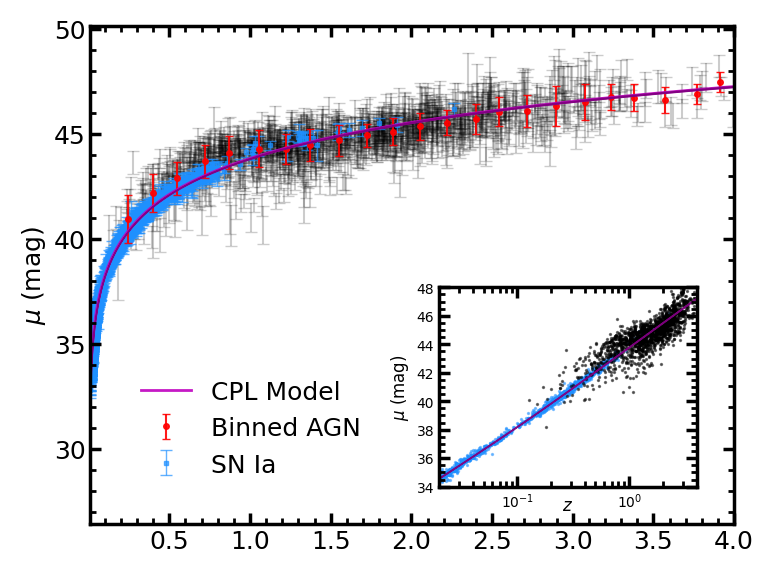

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import matplotlib.colors as colors
plt.style.use('style.mplstyle')

results = {key: np.percentile(flat_samples[:, i], [16, 50, 84]) for i, key in enumerate(priors.keys())}

def plot_hubble(flat_samples, filename="hubble_plot.png"):
    """Plot Hubble diagram + residuals, classic Pantheon+ style."""
    
    # --- Cosmology model ---
    z_grid = np.linspace(0.01, 4.0, len(df))
    mu_models = np.array([
        #FlatLambdaCDM(H0=s[-2], Om0=s[-1]).distmod(z_grid).value for s in flat_samples
        Flatw0waCDM(H0=s[-4], Om0=s[-3], w0=s[-2], wa=s[-1]).distmod(z_grid).value for s in flat_samples
    ])
    
    mu_model_median = np.percentile(mu_models, 50, axis=0)
    mu_model_16th = np.percentile(mu_models, 16, axis=0)
    mu_model_84th = np.percentile(mu_models, 84, axis=0)

    # --- AGN distance modulus ---
    Kcorr = K_corr(df['z']) + K_corr(2)
    mu_pred = np.array([
        df['apparent_mag_i'] - M_model_single(s[2], s[0], s[1], df['log_sigma_UV'], df['log_tau_UV_RF']) - Kcorr
        for s in flat_samples
    ])
    mu_pred_median = np.percentile(mu_pred, 50, axis=0)
    mu_pred_16th = np.percentile(mu_pred, 16, axis=0)
    mu_pred_84th = np.percentile(mu_pred, 84, axis=0)
    mu_pred_std = np.sqrt(df['apparent_mag_i_err']**2 +
            np.abs(0.5 * (mu_pred_84th - mu_pred_16th))**2 +
                 #(-2.5 * 0.3 * np.log10(1 + df["z"]))**2 +
                 (Kcorr * 0.05)**2 +
                (results["alpha"][1] * df['log_sigma_UV_err'])**2 +
                (results["delta"][1] * df['log_tau_UV_RF_err'])**2)
    

    # --- Binning ---
    bins = np.linspace(df["z"].min(),df["z"].max(), 25)
    bin_indices = np.digitize(df["z"], bins)
    binned_mu_pred_median = [np.median(mu_pred_median[bin_indices == i]) for i in range(1, len(bins))]
    binned_mu_pred_std = [np.std(mu_pred_median[bin_indices == i]) for i in range(1, len(bins))]
    binned_z = [np.median(df["z"][bin_indices == i]) for i in range(1, len(bins))]


    # --- Plot setup ---
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    inset_ax = inset_axes(ax, width="40%", height="40%", loc="lower right", borderpad=1.5)

    # --- Inset plot ---
    inset_ax.scatter(df["z"], mu_pred_median, s=2, label="AGN", alpha=0.5, color="black",zorder=-9)
    inset_ax.scatter(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], color="dodgerblue", s=2, label="SN Ia", alpha=0.5, zorder=-10)
    inset_ax.plot(z_grid, mu_model_median, alpha=0.9, color="purple", zorder=-9, lw=0.5, label="ΛCDM Model")
    inset_ax.fill_between(z_grid, mu_model_16th, mu_model_84th, color="purple", alpha=0.9)
    inset_ax.set_xscale('log')
    inset_ax.set_xlim(0.02, 4.0)
    inset_ax.set_ylim(34, 48)
    inset_ax.set_xlabel(r"$z$", fontsize=12, labelpad=-10)
    inset_ax.set_ylabel(r"$\mu$ (mag)", fontsize=12)
    inset_ax.tick_params(axis='both', which='major', labelsize=10)
#    inset_ax.legend(frameon=False, fontsize=6)

    # --- Main Hubble diagram ---
    # Original AGNs
    ax.errorbar(df["z"], mu_pred_median, yerr=mu_pred_std, fmt='none', linestyle='none',
                alpha=0.2, color='k', lw=1.5, zorder=-10)
    # Binned AGNs
    ax.errorbar(binned_z, binned_mu_pred_median, yerr=binned_mu_pred_std, fmt='o', markersize=4, capsize=3,
                label="Binned AGN", alpha=0.9, color="red", lw=1.5, zorder=-7)

    # SNIa points
    ax.errorbar(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], yerr=df_pantheon["MU_SH0ES_ERR_DIAG"], 
                fmt='s', markersize=3, color="dodgerblue", linestyle='none', lw=1, label="SN Ia", alpha=0.7, zorder=-8)

    # ΛCDM band
    ax.plot(z_grid, mu_model_median, alpha=0.9, color="m", zorder=-5, lw=2, label="CPL Model")
    ax.fill_between(z_grid, mu_model_16th, mu_model_84th, color="purple", alpha=0.9, zorder=-5)

    ax.set_ylabel(r"$\mu$ (mag)")
    #ax.set_xscale('log')
    ax.set_xlim(0.01, 4.0)
    #ax.set_ylim(32, 48)
    ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.25, 0.05))

    # Ticks styling
    for axi in [ax, inset_ax]:
        axi.minorticks_on()
        axi.tick_params(axis='both', which='minor', direction='in', length=4, top=True, right=True, width=2)
        axi.tick_params(axis='both', which='major', direction='in', length=8, top=True, right=True)

    fig.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

plot_hubble(flat_samples, filename="plots/hubble_diagram.pdf")

In [509]:
import numpy as np
import matplotlib.pyplot as plt
import corner
from matplotlib.lines import Line2D

# === Parameter setup ===
param_names = ["H0", "Om0", "w0", "wa"]
labels = [r"$H_0$", r"$\Omega_M$", r"$w_0$", r"$w_a$"]
param_indices = [list(priors.keys()).index(p) for p in param_names]

# === Flattened MCMC samples ===
sna_data = sampler_sna.get_chain(flat=True)[:, param_indices]
agn_data = sampler_agn.get_chain(flat=True)[:, param_indices]

# === Create base corner plot with SN Ia ===
fig = corner.corner(
    sna_data,
    labels=labels,
    color="blue",
    show_titles=False,
    plot_datapoints=False,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,
    contourf_kwargs={"alpha": 0.4},
    contour_kwargs={"linewidths": 1.2},
    levels=(0.393, 0.865),
    smooth=1.0,
    bins=60,
    hist_kwargs={"linewidth": 1.5},
)

# === Overlay AGN contours ===
corner.corner(
    agn_data,
    fig=fig,
    color="red",
    plot_datapoints=False,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,
    contourf_kwargs={"alpha": 0.4},
    contour_kwargs={"linewidths": 1.2},
    levels=(0.393, 0.865),
    smooth=1.0,
    bins=60,
    hist_kwargs={"linewidth": 1.5},
)

# === Posterior summary function ===
def posterior_summary(data, names):
    summaries = {}
    for i, name in enumerate(names):
        median = np.percentile(data[:, i], 50)
        plus = np.percentile(data[:, i], 84) - median
        minus = median - np.percentile(data[:, i], 16)
        summaries[name] = (median, plus, minus)
    return summaries

# === Compute summaries ===
sna_summary = posterior_summary(sna_data, param_names)
agn_summary = posterior_summary(agn_data, param_names)

# === Format summary text ===
summary_lines = []
for name in param_names:
    m1, p1, m1_ = sna_summary[name]
    m2, p2, m2_ = agn_summary[name]
    summary_lines.append(f"SN  {name}  = {m1:.2f} +{p1:.2f} -{m1_:.2f}")
    summary_lines.append(f"AGN {name} = {m2:.2f} +{p2:.2f} -{m2_:.2f}")
    summary_lines.append("")

# === Add summary in empty triangle corner ===
x_pos, y_pos = 0.68, 0.92
for i, line in enumerate(summary_lines):
    color = "blue" if "SN" in line else "red" if "AGN" in line else "black"
    fig.text(
        x_pos,
        y_pos - i * 0.035,
        line,
        fontsize=11,
        color=color,
        family="monospace",
        ha="left",
        va="top"
    )

# === Add legend ===
legend_elements = [
    Line2D([0], [0], color="blue", lw=2, label="SN Ia"),
    Line2D([0], [0], color="red", lw=2, label="SN Ia + AGN"),
]
fig.legend(handles=legend_elements, loc="upper right", fontsize=14, frameon=False)

# === Adjust layout and save ===
fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)
fig.savefig("corner_final_filled.pdf", bbox_inches="tight", transparent=True)
plt.show()


NameError: name 'sampler_sna' is not defined

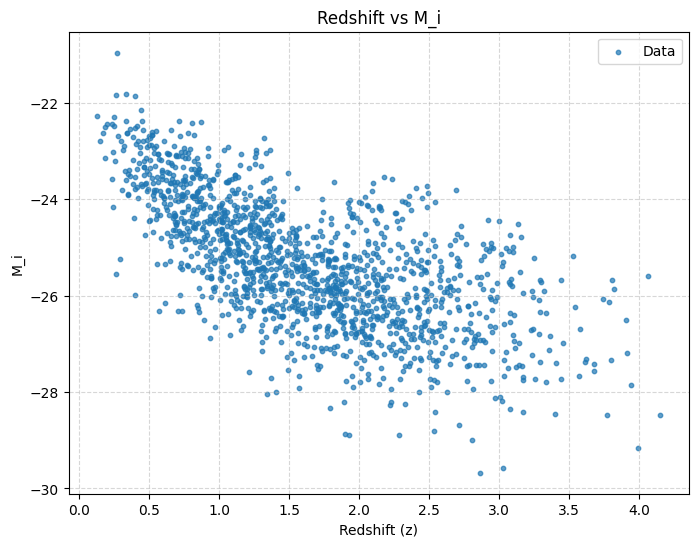

In [357]:
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['M_i'], alpha=0.7, s=10, label='Data')
plt.xlabel('Redshift (z)')
plt.ylabel('M_i')
plt.title('Redshift vs M_i')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [43]:
import math

# Define the number of redshift bins and their labels
num_bins = len(z_bins) - 1
bin_labels = [f"{z_bins[i]:.2f} < z < {z_bins[i+1]:.2f}" for i in range(num_bins)]

# Calculate the number of rows and columns for the grid
num_cols = 3  # Number of columns
num_rows = math.ceil(num_bins / num_cols)  # Number of rows

# Create subplots with reduced height
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows), sharey=True, sharex=True)
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

# Loop through each redshift bin and plot
for i, ax in enumerate(axes):
    ax.set_xlim(df['M_i'].min(), df['M_i'].max())
    ax.set_ylim(df['M_i'].min(), df['M_i'].max())

    if i < num_bins:
        # Filter data for the current redshift bin
        bin_mask = z_bin_indices == (i + 1)
        actual_M_i = df['M_i']
        predicted_M_i_bin = predicted_M_i[bin_mask]
        predicted_M_i_err_bin = mu_pred_std[bin_mask]  # Error for predictions
        M_i_axis = np.linspace(actual_M_i.min(), actual_M_i.max(), 100)
        ax.plot(M_i_axis, M_i_axis, color='k', alpha=0.7, label='y = x (Perfect Prediction)', lw=3)
        # Scatter plot for the current bin with error bars
        scatter = ax.errorbar(
            actual_M_i[bin_mask], predicted_M_i_bin, yerr=predicted_M_i_err_bin, fmt='o', alpha=0.7
        )
        # Invert x and y axes
        ax.invert_xaxis()
        ax.invert_yaxis()
        # Annotate bin label
        ax.annotate(bin_labels[i], xy=(0.05, 0.95), xycoords='axes fraction', 
                fontsize=18, color='k', alpha=0.7, ha='left', va='top')  # Annotate bin label in grey
        if i >= (num_rows - 1) * num_cols:  # Add xlabel only for the bottom row
            ax.set_xlabel('Actual $M_i$')
        if i % num_cols == 0:  # Add ylabel only for the first column
            ax.set_ylabel('Predicted $M_i$')
    else:
        # Hide unused subplots
        ax.axis('off')

# Adjust layout to remove whitespace
plt.subplots_adjust(wspace=0, hspace=0)

# Show the plot
plt.show()


NameError: name 'z_bins' is not defined

In [15]:
df.keys()

Index(['object_id', 'beta', 'beta_err', 'clean_bands', 'dec', 'delta',
       'delta_err', 'i', 'lag', 'lag_err',
       ...
       'apparent_mag_g', 'apparent_mag_u', 'apparent_mag_z_err',
       'apparent_mag_i_err', 'apparent_mag_r_err', 'apparent_mag_g_err',
       'apparent_mag_u_err', 'color', 'log_lambda_RF', 'delta_time'],
      dtype='object', length=103)

KeyError: 'delta'

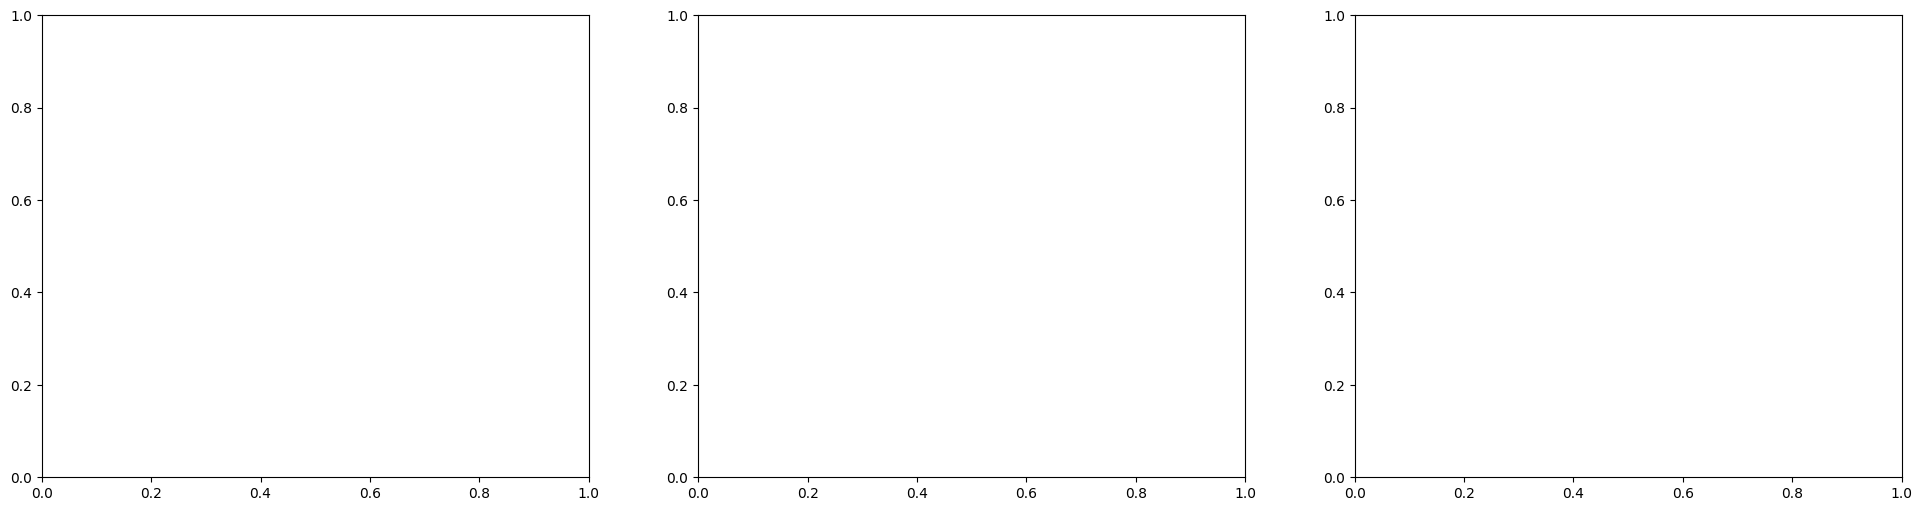

In [261]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=False)

# Left subfigure: Delta vs Redshift
axes[0].errorbar(df['z'], df['delta'], yerr=df['delta_err'], fmt='o', markersize=4, alpha=0.7, label='Delta Data', color='blue', lw=1)
axes[0].set_xlabel('Redshift (z)')
axes[0].set_ylabel('Delta')
axes[0].set_title('Delta vs Redshift with Errors')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Middle subfigure: Beta vs Redshift
axes[1].errorbar(df['z'], df['beta'], yerr=df['beta_err'], fmt='o', markersize=4, alpha=0.7, label='Beta Data', color='green', lw=1)
axes[1].set_xlabel('Redshift (z)')
axes[1].set_title('Beta vs Redshift with Errors')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

# Right subfigure: Ply1 vs Redshift
axes[2].errorbar(df['z'], df['poly1'], yerr=df['poly1_err'], fmt='o', markersize=4, alpha=0.7, label='Poly1 Data', color='purple', lw=1)
axes[2].set_xlabel('Redshift (z)')
axes[2].set_title('poly1 vs Redshift')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_1456773/2318474293.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


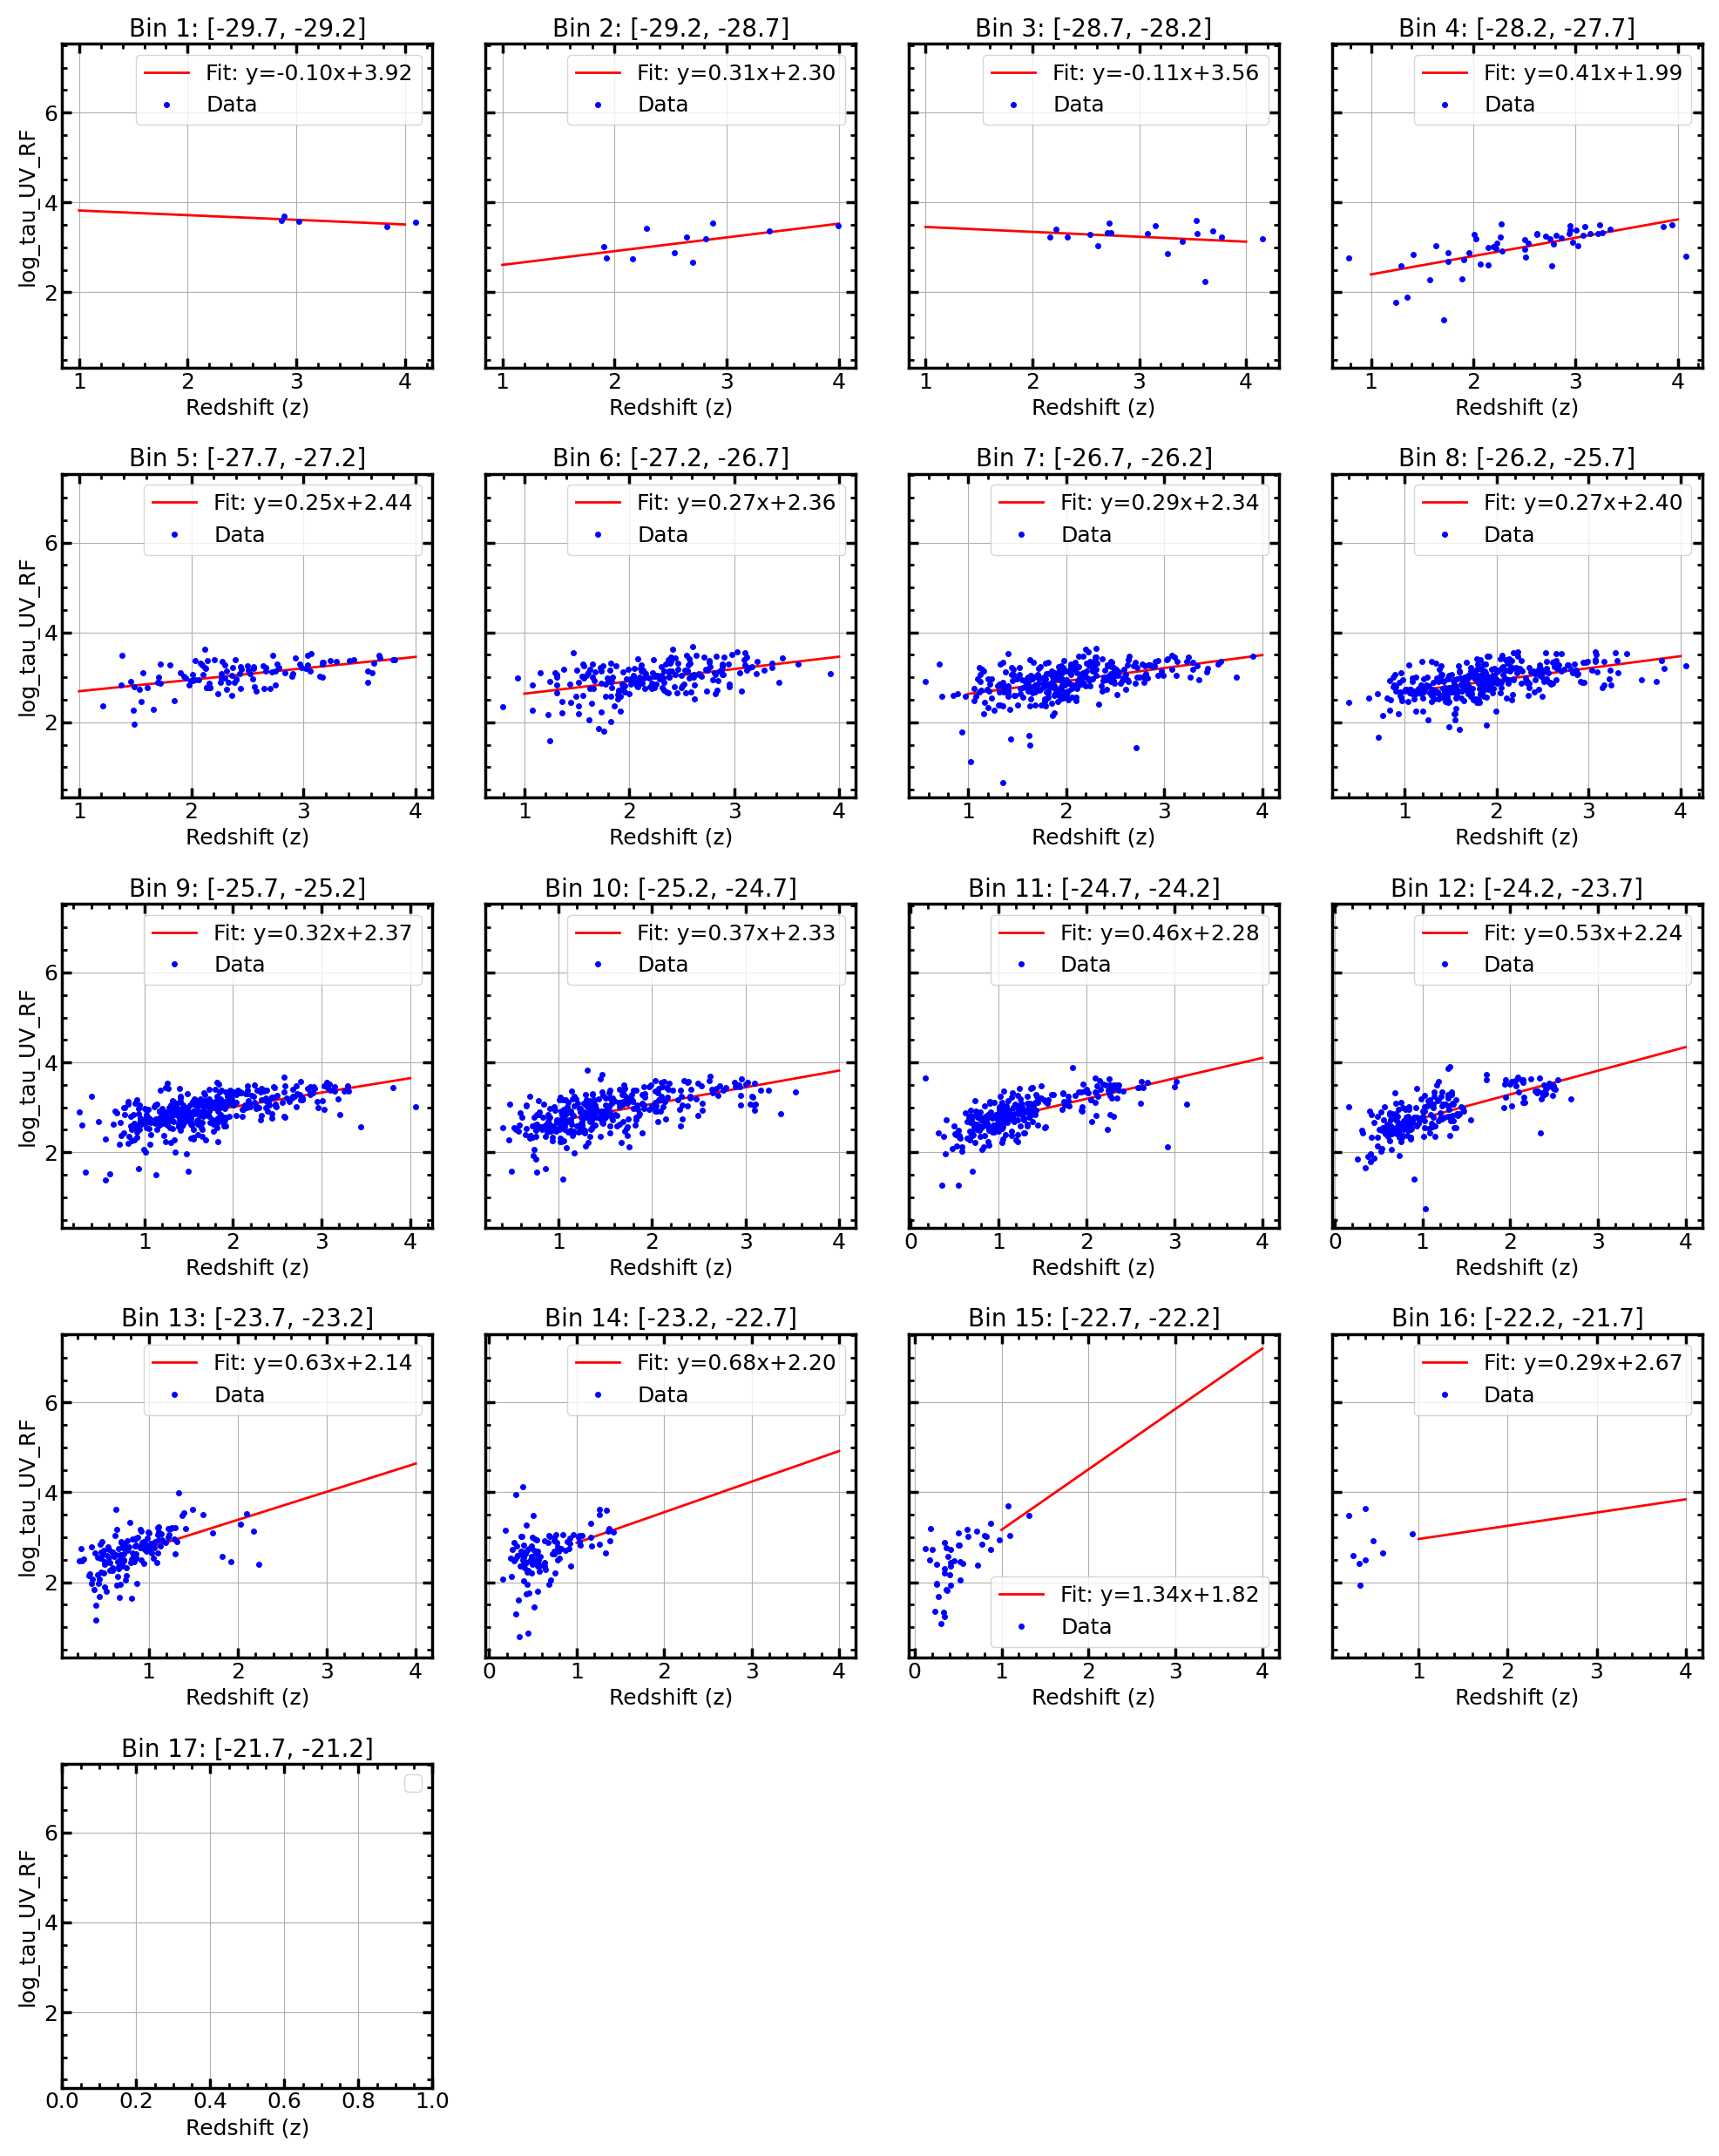

In [44]:
from scipy.stats import linregress

# Define the bins for M_i
M_i_bins = np.arange(df['M_i'].min(), df['M_i'].max(), 0.5)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(M_i_bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Fit a line to the data in each panel
for i in range(len(M_i_bins) - 1):
    bin_mask = (df['M_i'] >= M_i_bins[i]) & (df['M_i'] < M_i_bins[i + 1])
    bin_data = df[bin_mask]
    
    if len(bin_data) > 1:  # Ensure there are enough points to fit a line
        slope, intercept, r_value, p_value, std_err = linregress(bin_data['z'], bin_data['log_tau_UV_RF'])
        y_vals = slope * np.linspace(1, 4) + intercept
        axes[i].plot(np.linspace(1, 4), y_vals, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        axes[i].plot(bin_data['z'], bin_data['log_tau_UV_RF'], 'bo', label='Data')
        axes[i].legend()
    axes[i].set_title(f'Bin {i+1}: [{M_i_bins[i]:.1f}, {M_i_bins[i+1]:.1f}]')
    axes[i].set_xlabel('Redshift (z)')
    if i % 4 == 0:
        axes[i].set_ylabel('log_tau_UV_RF')
    axes[i].grid(True)
    axes[i].legend()

# Hide unused subplots
for j in range(len(M_i_bins) - 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1456773/667366755.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


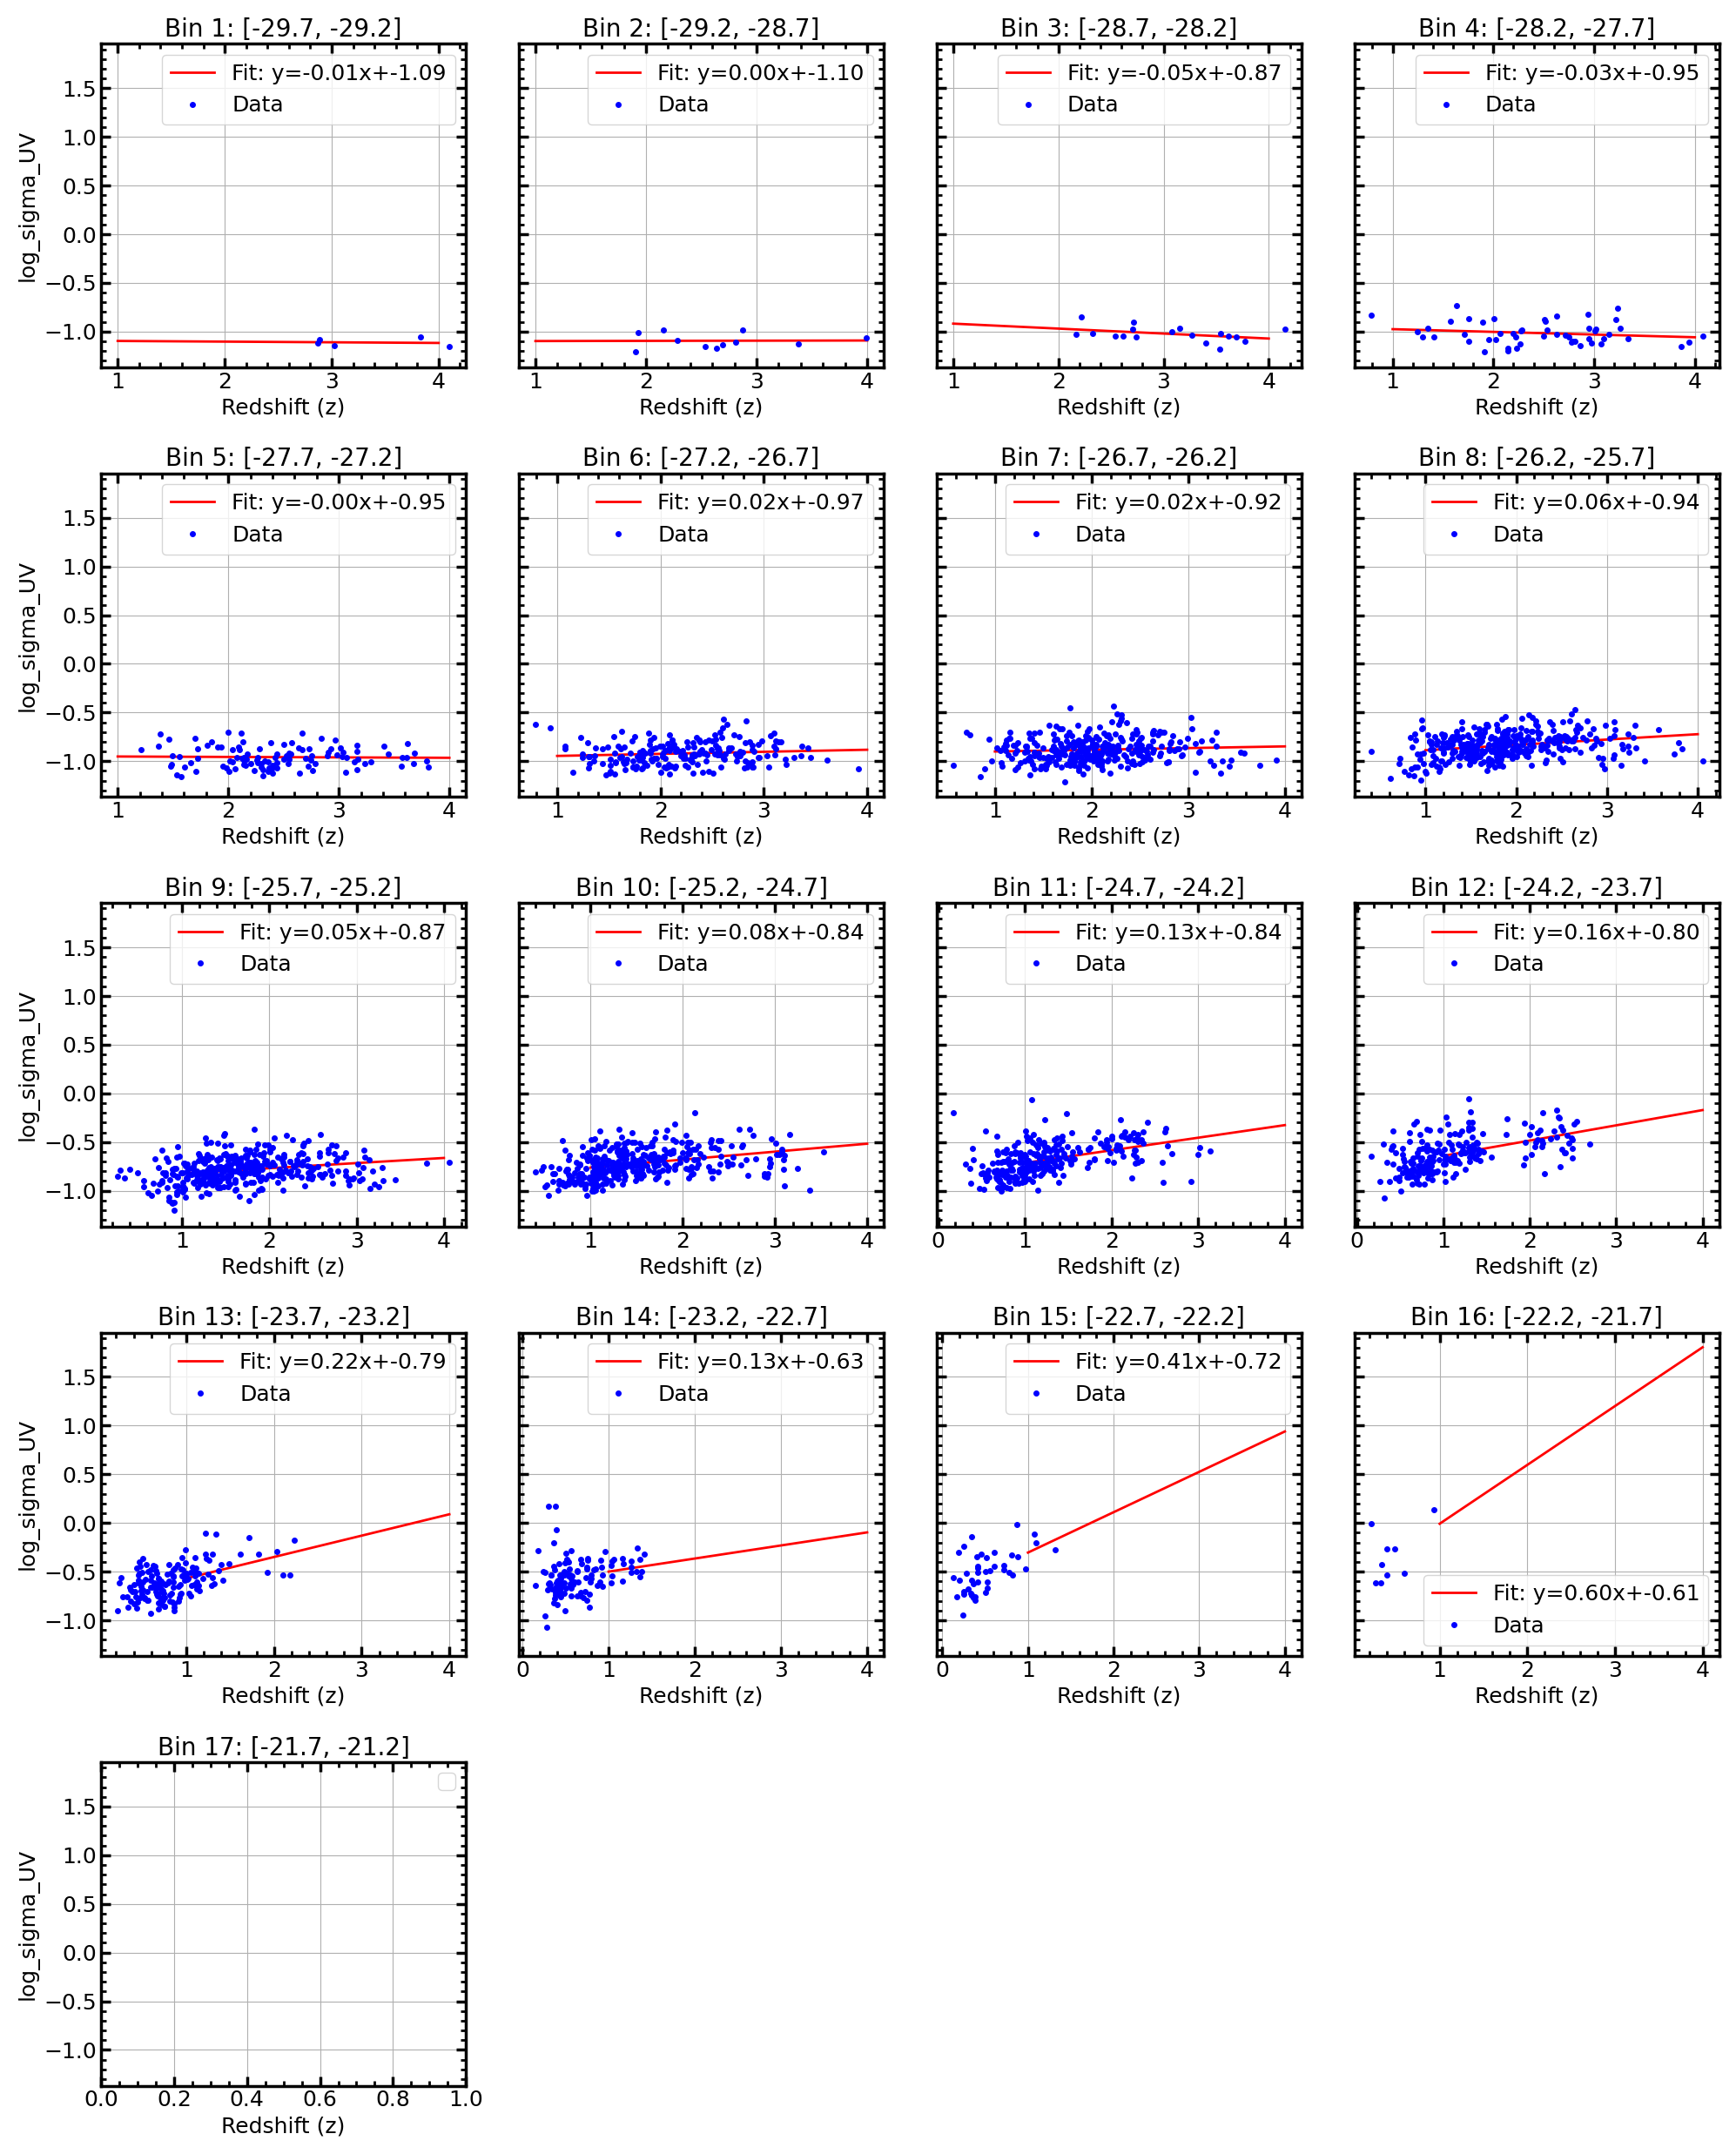

In [45]:
from scipy.stats import linregress

# Define the bins for M_i
M_i_bins = np.arange(df['M_i'].min(), df['M_i'].max(), 0.5)

# Calculate the number of rows needed for a grid with 4 columns
n_rows = int(np.ceil(len(M_i_bins) / 4))

# Create subplots in a grid with 4 columns
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5 * n_rows), sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier indexing

# Fit a line to the data in each panel
for i in range(len(M_i_bins) - 1):
    bin_mask = (df['M_i'] >= M_i_bins[i]) & (df['M_i'] < M_i_bins[i + 1])
    bin_data = df[bin_mask]
    
    if len(bin_data) > 1:  # Ensure there are enough points to fit a line
        slope, intercept, r_value, p_value, std_err = linregress(bin_data['z'], bin_data['log_sigma_UV'])
        y_vals = slope * np.linspace(1, 4) + intercept
        axes[i].plot(np.linspace(1, 4), y_vals, 'r-', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        axes[i].plot(bin_data['z'], bin_data['log_sigma_UV'], 'bo', label='Data')
        axes[i].legend()
    axes[i].set_title(f'Bin {i+1}: [{M_i_bins[i]:.1f}, {M_i_bins[i+1]:.1f}]')
    axes[i].set_xlabel('Redshift (z)')
    if i % 4 == 0:
        axes[i].set_ylabel('log_sigma_UV')
    axes[i].grid(True)
    axes[i].legend()

# Hide unused subplots
for j in range(len(M_i_bins) - 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()